# Chapter 169 — Eigenvectors: Intuition

> **Prerequisites:** ch164 (Linear Transformations), ch165 (Matrix Transformations Visualization), ch154 (Matrix Multiplication)
> **You will learn:**
> - What an eigenvector is geometrically
> - Why eigenvectors reveal the "skeleton" of a transformation
> - How to identify eigenvectors visually before computing them
> - Why most vectors are NOT eigenvectors
> **Environment:** Python 3.x, numpy, matplotlib

## 1. Concept

Most vectors, when multiplied by a matrix, change both **direction** and **length**. An eigenvector is special: when a matrix acts on it, the direction is preserved. Only the length (and possibly sign) changes.

Formally: **v** is an eigenvector of matrix **A** if:

    A v = λ v

The scalar λ (lambda) is the corresponding eigenvalue. The matrix stretches (or flips) **v** by exactly λ — no rotation, no oblique shift.

**Common misconception:** Eigenvectors are not special because they are short or axis-aligned. A matrix can have eigenvectors in any direction. What makes them special is the *behavior under the transformation*, not their coordinates.

**Common misconception 2:** Not every matrix has real eigenvectors. Rotation matrices (except 0° and 180°) have no real eigenvectors — every vector changes direction.

## 2. Intuition & Mental Models

**Geometric:** Think of a matrix as a machine that pushes and pulls space. Most points get swept sideways. But some directions are "stiff" — they resist the sideways push and only get scaled. Those are the eigendirections.

**Physical:** Imagine stretching a piece of rubber. The grain of the rubber (the direction it was already oriented) stretches along its own axis. Vectors perpendicular to the grain get pulled off-axis. The grain direction is the eigenvector.

**Computational:** Think of A as a function f(v) = Av. An eigenvector is a fixed direction of f — a direction where f acts like scalar multiplication. From a function perspective: eigenvectors are the directions where a linear map *decouples*.

Recall from ch164 that a linear transformation maps lines through the origin to lines through the origin. An eigenvector is a line through the origin that maps to *itself* (as a line, not necessarily as a point).

## 3. Visualization

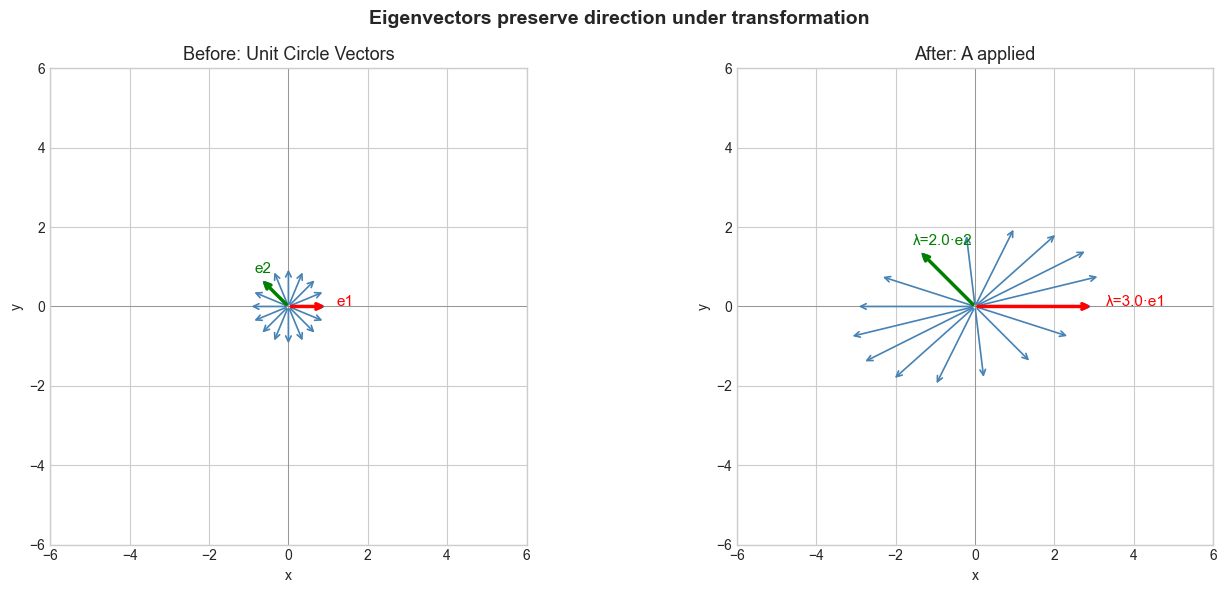

Eigenvalues: [3. 2.]
Eigenvectors (columns):
[[ 1.         -0.70710678]
 [ 0.          0.70710678]]


In [1]:
# --- Visualization: Eigenvectors as direction-preserving vectors ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# A matrix with known eigenvectors for demonstration
A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

# True eigenvectors (computed analytically for this matrix)
# A is upper triangular -> eigenvalues are diagonal entries: 3, 2
# eigenvector for lambda=3: [1, 0]
# eigenvector for lambda=2: [1, -1] (normalized)
eigvals, eigvecs = np.linalg.eig(A)

# Sample random vectors on the unit circle
N_VECTORS = 16
angles = np.linspace(0, 2 * np.pi, N_VECTORS, endpoint=False)
vecs = np.stack([np.cos(angles), np.sin(angles)], axis=1)  # shape (N, 2)

# Apply transformation
transformed = (A @ vecs.T).T  # shape (N, 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (vset, title) in zip(axes, [(vecs, 'Before: Unit Circle Vectors'),
                                     (transformed, 'After: A applied')]):
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    for v in vset:
        ax.annotate('', xy=v, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

# Highlight eigenvectors on both plots
for i, (ev, lam) in enumerate(zip(eigvecs.T, eigvals)):
    ev_norm = ev / np.linalg.norm(ev)
    ev_scaled = ev_norm * lam  # where it maps to
    color = ['red', 'green'][i]
    axes[0].annotate('', xy=ev_norm, xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    axes[0].text(ev_norm[0]*1.2, ev_norm[1]*1.2, f'e{i+1}', color=color, fontsize=11)
    axes[1].annotate('', xy=ev_scaled, xytext=(0, 0),
                     arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    axes[1].text(ev_scaled[0]*1.1, ev_scaled[1]*1.1,
                 f'λ={lam:.1f}·e{i+1}', color=color, fontsize=11)

plt.suptitle('Eigenvectors preserve direction under transformation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Eigenvalues: {eigvals}")
print(f"Eigenvectors (columns):\n{eigvecs}")

## 4. Mathematical Formulation

**Definition:** Given an n×n matrix **A**, a nonzero vector **v** ∈ ℝⁿ is an eigenvector if:

    A v = λ v

Where:
- **A** = the transformation matrix (n×n)
- **v** = eigenvector (n×1, nonzero by definition)
- **λ** = eigenvalue (scalar)

**Rearranged:** A v - λ v = 0 → (A - λI)v = 0

For this to have a nonzero solution **v**, the matrix (A - λI) must be singular:

    det(A - λI) = 0

This is the **characteristic equation** — the polynomial whose roots are the eigenvalues. We cover it fully in ch170 (Eigenvalues Intuition) and ch171 (Eigenvalue Computation).

**Key facts:**
- An n×n matrix has at most n eigenvalues (counted with multiplicity)
- Eigenvectors are not unique: if **v** is an eigenvector, so is c**v** for any nonzero scalar c
- The set of all eigenvectors for a given λ (plus zero) forms a subspace called the **eigenspace**

In [2]:
# Worked numeric example
import numpy as np

A = np.array([[3.0, 1.0],
              [0.0, 2.0]])

# Verify eigenvector by hand: v = [1, 0], lambda = 3
v1 = np.array([1.0, 0.0])
lam1 = 3.0

lhs = A @ v1       # A v
rhs = lam1 * v1    # λ v

print("A @ v1 =", lhs)
print("lam1 * v1 =", rhs)
print("Equal?", np.allclose(lhs, rhs))

# Verify second eigenvector: v = [1, -1], lambda = 2
v2 = np.array([1.0, -1.0])
lam2 = 2.0
print("\nA @ v2 =", A @ v2)
print("lam2 * v2 =", lam2 * v2)
print("Equal?", np.allclose(A @ v2, lam2 * v2))

A @ v1 = [3. 0.]
lam1 * v1 = [3. 0.]
Equal? True

A @ v2 = [ 2. -2.]
lam2 * v2 = [ 2. -2.]
Equal? True


## 5. Python Implementation

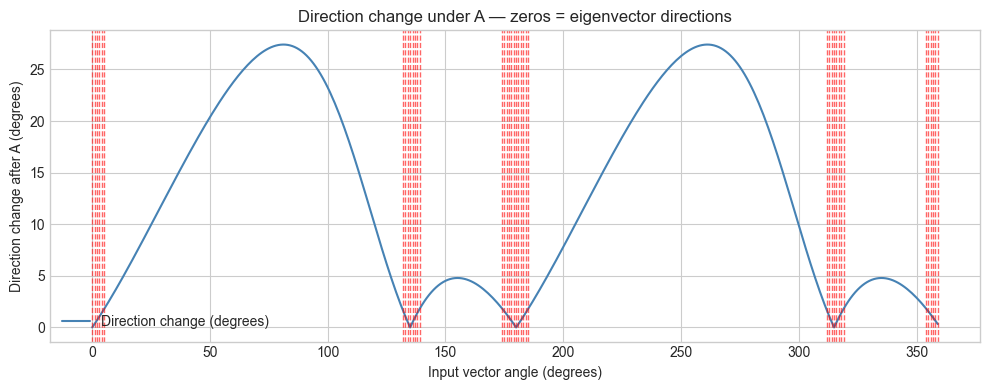

Approximate eigenvector directions: [  0.   1.   2.   3.   4.   5. 132. 133. 134. 135. 136. 137. 138. 139.
 174. 175. 176. 177. 178. 179. 180. 181. 182. 183. 184. 185. 312. 313.
 314. 315. 316. 317. 318. 319. 354. 355. 356. 357. 358. 359.]°


In [3]:
# --- Implementation: Visualizing direction change for all unit vectors ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def angle_change(A, n_samples=360):
    """
    For each unit vector at angle theta, compute how much its direction
    changes after applying matrix A.

    Args:
        A: (2,2) matrix
        n_samples: number of angles to sample

    Returns:
        angles: input angles in degrees
        delta: direction change in degrees after applying A
    """
    angles = np.linspace(0, 360, n_samples, endpoint=False)
    deltas = []
    for theta in angles:
        rad = np.radians(theta)
        v = np.array([np.cos(rad), np.sin(rad)])
        Av = A @ v
        # Angle of transformed vector
        out_angle = np.degrees(np.arctan2(Av[1], Av[0])) % 360
        delta = abs((out_angle - theta + 180) % 360 - 180)  # signed wrap
        deltas.append(delta)
    return angles, np.array(deltas)

A = np.array([[3.0, 1.0], [0.0, 2.0]])
angles, deltas = angle_change(A)

# Find angles where direction change ≈ 0 (eigenvector directions)
eigen_angles = angles[deltas < 2.0]

plt.figure(figsize=(10, 4))
plt.plot(angles, deltas, 'steelblue', lw=1.5, label='Direction change (degrees)')
for ea in eigen_angles:
    plt.axvline(ea, color='red', ls='--', alpha=0.6, lw=1)
plt.xlabel('Input vector angle (degrees)')
plt.ylabel('Direction change after A (degrees)')
plt.title('Direction change under A — zeros = eigenvector directions')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Approximate eigenvector directions: {eigen_angles}°")

## 6. Experiments

In [4]:
# --- Experiment 1: Rotation matrix has no real eigenvectors ---
# Hypothesis: A pure rotation has no direction that is preserved
# Try changing: THETA to 0 or 180 degrees and observe what happens

import numpy as np
THETA = 45  # degrees -- try: 0, 90, 180, 45

rad = np.radians(THETA)
R = np.array([[np.cos(rad), -np.sin(rad)],
              [np.sin(rad),  np.cos(rad)]])

eigvals = np.linalg.eigvals(R)
print(f"Rotation by {THETA}°")
print(f"Eigenvalues: {eigvals}")
print(f"Real? {np.all(np.isreal(eigvals))}")
print("Note: complex eigenvalues mean no real eigenvectors")

Rotation by 45°
Eigenvalues: [0.70710678+0.70710678j 0.70710678-0.70710678j]
Real? False
Note: complex eigenvalues mean no real eigenvectors


In [5]:
# --- Experiment 2: Symmetric matrix always has real eigenvectors ---
# Hypothesis: Symmetric matrices always have real, orthogonal eigenvectors
# Try changing: the off-diagonal entries

import numpy as np

OFF_DIAG = 2.0  # try: 0, 1, 3, -2

S = np.array([[4.0, OFF_DIAG],
              [OFF_DIAG, 1.0]])  # symmetric by construction

eigvals, eigvecs = np.linalg.eig(S)
print(f"Matrix S with off-diagonal = {OFF_DIAG}:")
print(S)
print(f"Eigenvalues: {eigvals}")
print(f"Eigenvectors (columns):\n{eigvecs}")
print(f"Dot product of eigenvectors (should be 0): {eigvecs[:,0] @ eigvecs[:,1]:.6f}")

Matrix S with off-diagonal = 2.0:
[[4. 2.]
 [2. 1.]]
Eigenvalues: [5. 0.]
Eigenvectors (columns):
[[ 0.89442719 -0.4472136 ]
 [ 0.4472136   0.89442719]]
Dot product of eigenvectors (should be 0): 0.000000


In [6]:
# --- Experiment 3: Power iteration finds dominant eigenvector ---
# Hypothesis: Repeatedly applying A and normalizing converges to the
#             eigenvector with the largest eigenvalue
# Try changing: N_ITER and the initial vector

import numpy as np

N_ITER = 20  # try: 5, 10, 50

A = np.array([[3.0, 1.0], [0.0, 2.0]])
v = np.array([0.5, 0.5])  # arbitrary starting vector
v = v / np.linalg.norm(v)

history = [v.copy()]
for _ in range(N_ITER):
    v = A @ v
    v = v / np.linalg.norm(v)  # normalize to stay on unit sphere
    history.append(v.copy())

true_evec = np.linalg.eig(A)[1][:, 0]  # dominant eigenvector
true_evec /= np.linalg.norm(true_evec)

print(f"After {N_ITER} iterations: {v}")
print(f"True dominant eigenvector: {true_evec}")
print(f"Angle between them: {np.degrees(np.arccos(abs(v @ true_evec))):.4f}°")

After 20 iterations: [9.99999989e-01 1.50386941e-04]
True dominant eigenvector: [1. 0.]
Angle between them: 0.0086°


## 7. Exercises

**Easy 1.** By inspection (no computation), state one eigenvector of the identity matrix I and its eigenvalue. *(Expected: any nonzero vector, λ=1)*

**Easy 2.** For a diagonal matrix D = diag(5, 3), what are the eigenvectors and eigenvalues? Write code to verify.

**Medium 1.** Show that if **v** is an eigenvector of **A** with eigenvalue λ, then **v** is also an eigenvector of **A²** (A squared) with eigenvalue λ². Write a proof in code: construct a matrix, find an eigenvector, verify for A².

**Medium 2.** Build the `angle_change` function for a 2D shear matrix `[[1, k], [0, 1]]`. Plot the direction change as a function of k (try k = 0, 0.5, 1, 2). What do you observe about the eigenvector direction as k increases?

**Hard.** A projection matrix P satisfies P² = P *(introduced in ch168 — Projection Matrices)*. Prove algebraically that the only possible eigenvalues of a projection matrix are 0 and 1. Then construct a 3×3 projection matrix and verify numerically.

## 8. Mini Project: Iterative Direction Finder

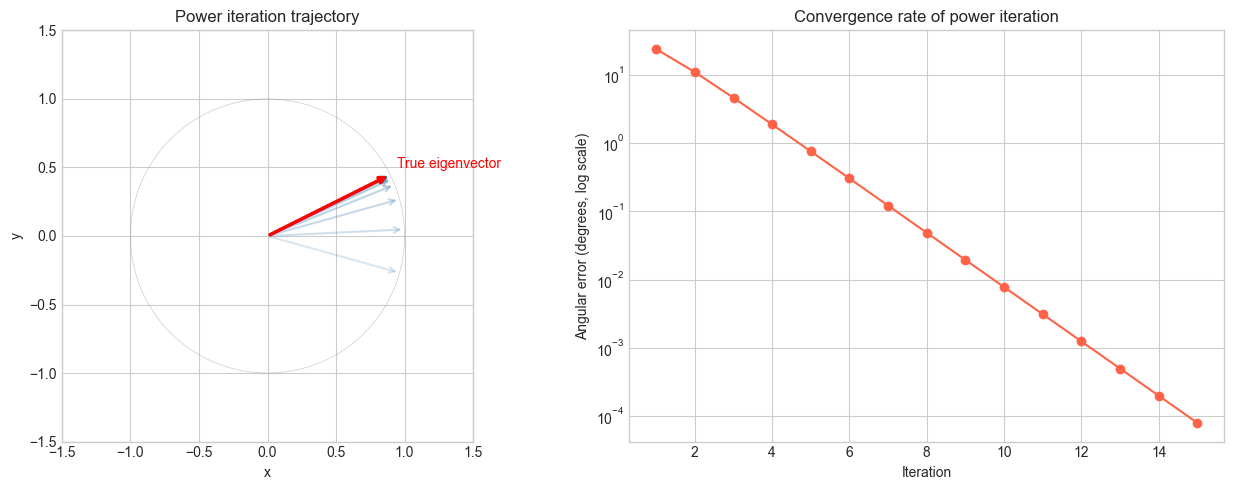

Eigenvalues: [5. 2.]
Ratio |λ2/λ1| = 0.400
Convergence rate is determined by this ratio


In [7]:
# --- Mini Project: Visualize power iteration convergence ---
# Problem: Animate how a random vector converges to the dominant eigenvector
#          of a 2x2 matrix under repeated normalized multiplication.
# Task: Complete the animation and measure convergence rate.

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# TODO: Try modifying this matrix
A = np.array([[4.0, 2.0],
              [1.0, 3.0]])

eigvals, eigvecs = np.linalg.eig(A)
dominant_idx = np.argmax(np.abs(eigvals))
true_evec = eigvecs[:, dominant_idx]
true_evec /= np.linalg.norm(true_evec)

# Run power iteration
np.random.seed(42)
v = np.random.randn(2)
v /= np.linalg.norm(v)

N_STEPS = 15
history = [v.copy()]
errors = []

for _ in range(N_STEPS):
    v = A @ v
    v /= np.linalg.norm(v)
    history.append(v.copy())
    # Angle error (account for sign ambiguity)
    err = np.degrees(np.arccos(min(1.0, abs(v @ true_evec))))
    errors.append(err)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot trajectory of iterates
ax = axes[0]
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), 'gray', lw=0.5, alpha=0.4)
for i, h in enumerate(history):
    alpha = 0.2 + 0.8 * i / len(history)
    ax.annotate('', xy=h, xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5, alpha=alpha))
ax.annotate('', xy=true_evec, xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.text(true_evec[0]+0.05, true_evec[1]+0.05, 'True eigenvector', color='red')
ax.set_title('Power iteration trajectory')
ax.set_xlabel('x'); ax.set_ylabel('y')

# Plot error over iterations
axes[1].semilogy(range(1, N_STEPS+1), np.array(errors)+1e-10, 'o-', color='tomato')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Angular error (degrees, log scale)')
axes[1].set_title('Convergence rate of power iteration')

plt.tight_layout()
plt.show()
print(f"Eigenvalues: {eigvals}")
print(f"Ratio |λ2/λ1| = {min(abs(eigvals))/max(abs(eigvals)):.3f}")
print("Convergence rate is determined by this ratio")

## 9. Chapter Summary & Connections

- An eigenvector of matrix A is a nonzero vector that A maps to a scalar multiple of itself: Av = λv.
- The eigenvalue λ captures the scaling factor — positive means same direction, negative means flip, |λ|>1 means stretch.
- Most vectors are NOT eigenvectors. Rotation matrices have no real eigenvectors; symmetric matrices always do.
- Power iteration is a simple algorithm that converges to the dominant eigenvector by repeated normalized multiplication.
- The characteristic equation det(A - λI) = 0 produces eigenvalues — covered in ch170.

**Backward:** This builds directly on ch164 (Linear Transformations) — eigenvectors are the fixed lines of a linear map, and ch168 (Projection Matrices) which already showed a special case where Pv = v or Pv = 0.

**Forward:**
- ch170 (Eigenvalues Intuition): the complementary scalar quantity — where do eigenvalues come from?
- ch172 (Diagonalization): using eigenvectors to decompose a matrix into its simplest form
- ch173 (SVD): the generalization to non-square matrices — replaces eigenvectors with singular vectors
- ch174 (PCA): the dominant eigenvectors of a covariance matrix become the principal components

**Going deeper:** The spectral theorem guarantees that real symmetric matrices have a full set of real, orthogonal eigenvectors. This is the theoretical foundation of PCA and much of numerical linear algebra.